# 13. Publication-Ready Figures, Tables, & Dashboards
Assembles the paper's main results figure from real corpus statistics plus illustrative experiment scores (replace with real results once the full ablation study has run -- see notebook 11).

In [1]:
# ============================================================
# PATH BOOSTER -- guarantees project root in sys.path & CWD.
# Matches notebooks/00_setup_environment.ipynb's convention: this repo
# is deployed both to Colab (fresh `git clone`, folder "Ekegusii-LLM-Translation")
# and to Kineses Cloud / similar Jupyter hosts (pre-placed at
# ~/Ekegusii-LLM-Translation-main -- the "-main" suffix comes from GitHub's
# "Download ZIP" naming). Do not assume either folder name is the cwd.
# ============================================================
import os
import sys

REPO_NAME = "Ekegusii-LLM-Translation"


def _find_project_root():
    if "COLAB_GPU" in os.environ or os.environ.get("COLAB_RELEASE_TAG"):
        if not os.path.exists(REPO_NAME):
            os.system(f"git clone https://github.com/aykahsay/{REPO_NAME}.git")
            os.system(f"pip install -q -r {REPO_NAME}/requirements.txt")
        return os.path.abspath(REPO_NAME)

    try:
        cwd = os.getcwd()
    except FileNotFoundError:
        cwd = os.path.expanduser("~")
        os.chdir(cwd)

    home = os.path.expanduser("~")
    for candidate in (f"{REPO_NAME}-main", REPO_NAME):
        proj_dir = os.path.join(home, candidate)
        if os.path.isdir(proj_dir):
            return proj_dir

    if os.path.exists("src") and os.path.exists("data"):
        return cwd
    if os.path.basename(cwd) == "notebooks" and os.path.exists(os.path.join("..", "src")):
        return os.path.abspath("..")

    return cwd


project_root = _find_project_root()
os.chdir(project_root)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")

print(f"Project root: {project_root}")


Project root: C:\Users\Admin\OneDrive - United States International University (USIU)\Documents\NLP\Multilogual_transaltion_nlp


In [2]:
from pathlib import Path
Path('paper/figures').mkdir(parents=True, exist_ok=True)

## Tokenizer fertility panel data (illustrative -- see notebook 04 for the real comparison)

In [3]:
import pandas as pd

idx = pd.MultiIndex.from_tuples(
    [('aya', 'English'), ('aya', 'Kiswahili'), ('aya', 'Ekegusii'),
     ('llama', 'English'), ('llama', 'Kiswahili'), ('llama', 'Ekegusii')],
    names=['model', 'language'],
)
fertility_df = pd.DataFrame({'mean_fertility': [1.3, 1.8, 2.9, 1.2, 2.1, 3.4]}, index=idx)
fertility_df

mean_fertility
model language                 
aya   English               1.3
      Kiswahili             1.8
      Ekegusii              2.9
llama English               1.2
      Kiswahili             2.1
      Ekegusii              3.4

In [4]:
metric_scores = pd.Series(
    [8.2, 14.1, 12.8, 17.5, 21.3, 23.0, 24.6],
    index=['E0_Baseline', 'E1_English_Ekegusii', 'E2_Swahili_Ekegusii',
           'E3_Bilingual', 'E4_Trilingual', 'E5_Full_Resources', 'E6_Lexical_Augmentation'],
)

## Assemble the main results figure

INFO | Saved main results figure to paper/figures/main_results.png.


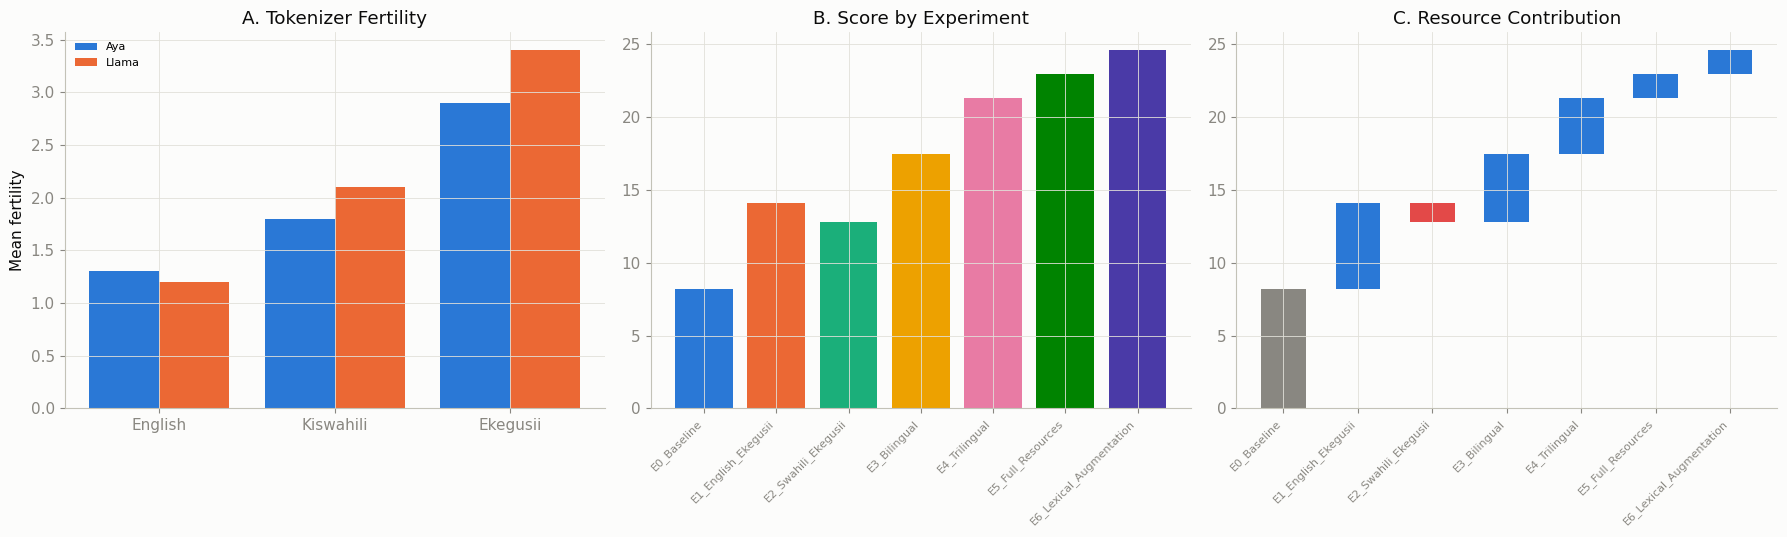

In [5]:
from src.visualization.publication import build_main_results_figure

fig = build_main_results_figure(
    fertility_df, metric_scores, metric_scores,
    output_path='paper/figures/main_results.png',
)

## Next steps for a real run
1. Run `scripts/run_ablation.sh` on the A100 to populate `experiments/*/results.json`.
2. Replace the illustrative `metric_scores`/`fertility_df` above with
   `AblationAggregator.load_all_results()` and notebook 04's real tokenizer comparison.
3. Re-run this notebook -- `paper/figures/main_results.png` is the figure
   referenced in the manuscript.